# Orthogonality of Complex Exponentials on $[-\pi,\pi]$

For integer modes $m,n$, define

$$
\phi_m(x)=e^{imx}
$$

and the complex inner product

$$
\langle f,g\rangle = \int_{-\pi}^{\pi} f(x)\,\overline{g(x)}\,dx.
$$

Then

$$
\langle e^{imx}, e^{inx}\rangle = \int_{-\pi}^{\pi} e^{i(m-n)x}\,dx = 2\pi\,\delta_{mn}.
$$

So different modes are orthogonal, and each mode has norm-squared $2\pi$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Grid on [-pi, pi]
x = np.linspace(-np.pi, np.pi, 20001)


def inner_product_complex(f_vals, g_vals, x_grid):
    return np.trapezoid(f_vals * np.conjugate(g_vals), x_grid)


def exp_mode(k, x_grid):
    return np.exp(1j * k * x_grid)

# Symmetric set of modes
modes = np.arange(-6, 7)

E = np.zeros((len(modes), len(modes)), dtype=complex)
for i, m in enumerate(modes):
    for j, n in enumerate(modes):
        E[i, j] = inner_product_complex(exp_mode(m, x), exp_mode(n, x), x)

print('Modes:', modes)
print('\nReal part of <e^{imx}, e^{inx}> ≈')
print(np.round(E.real, 6))
print('\nImaginary part (should be near 0) ≈')
print(np.round(E.imag, 6))

Modes: [-6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6]

Real part of <e^{imx}, e^{inx}> ≈
[[ 6.283185  0.       -0.        0.       -0.        0.       -0.
   0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.        6.283185  0.       -0.        0.       -0.        0.
  -0.        0.       -0.        0.       -0.        0.      ]
 [-0.        0.        6.283185  0.       -0.        0.       -0.
   0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.       -0.        0.        6.283185  0.       -0.        0.
  -0.        0.       -0.        0.       -0.        0.      ]
 [-0.        0.       -0.        0.        6.283185  0.       -0.
   0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.       -0.        0.       -0.        0.        6.283185  0.
  -0.        0.       -0.        0.       -0.        0.      ]
 [-0.        0.       -0.        0.       -0.        0.        6.283185
   0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.   

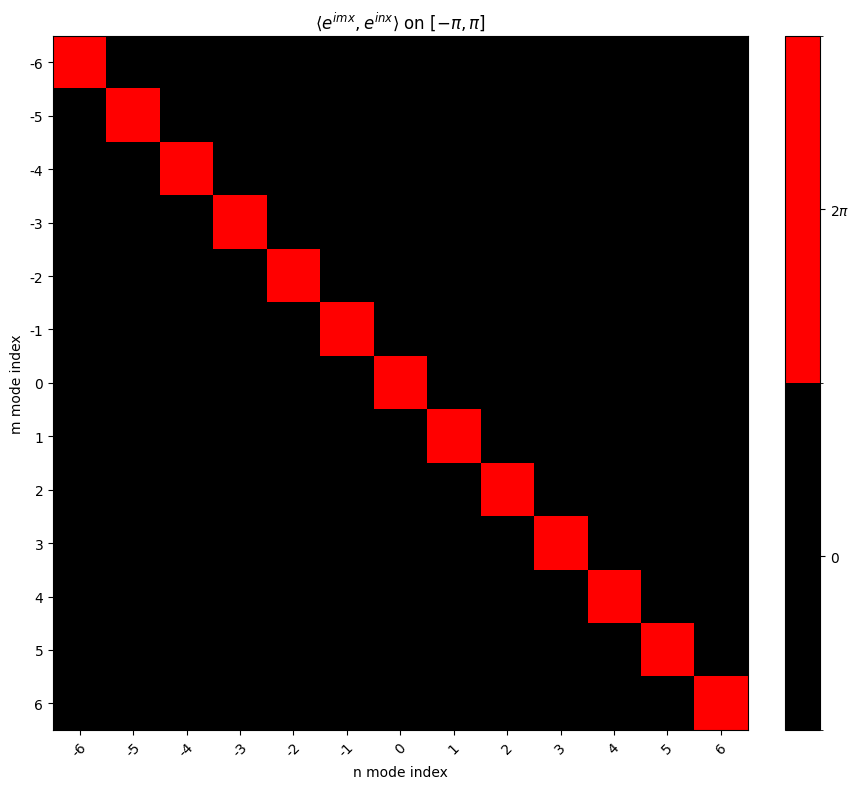

In [2]:
# Snap values to 0 or 2pi for a clean orthogonality view
tol = 1e-6
E_real = E.real
E_snap = np.zeros_like(E_real)
E_snap[np.isclose(E_real, 2 * np.pi, atol=tol)] = 2 * np.pi

E_plot = np.zeros_like(E_snap, dtype=int)
E_plot[np.isclose(E_snap, 2 * np.pi)] = 1  # 0->black, 1->red

cmap = ListedColormap(['black', 'red'])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(E_plot, cmap=cmap, norm=norm)
ax.set_title(r'$\langle e^{imx}, e^{inx}\rangle$ on $[-\pi,\pi]$')
ax.set_xlabel('n mode index')
ax.set_ylabel('m mode index')
ax.set_xticks(range(len(modes)))
ax.set_yticks(range(len(modes)))
ax.set_xticklabels(modes, rotation=45)
ax.set_yticklabels(modes)
cb = fig.colorbar(im, ax=ax, ticks=[0, 1], fraction=0.046, pad=0.04)
cb.ax.set_yticklabels(['0', r'$2\pi$'])

plt.tight_layout()
plt.show()

## Non-conjugated integral comparison

Now compare with

$$
I_{mn} = \int_{-\pi}^{\pi} e^{imx}e^{inx}\,dx = \int_{-\pi}^{\pi} e^{i(m+n)x}\,dx.
$$

For integer modes, this equals $2\pi$ when $m+n=0$ (i.e. $n=-m$), and $0$ otherwise.
So the bright line appears on the anti-diagonal instead of the main diagonal.

Real part of non-conjugated integral ≈
[[-0.        0.       -0.        0.       -0.        0.       -0.
   0.       -0.        0.       -0.        0.        6.283185]
 [ 0.       -0.        0.       -0.        0.       -0.        0.
  -0.        0.       -0.        0.        6.283185  0.      ]
 [-0.        0.       -0.        0.       -0.        0.       -0.
   0.       -0.        0.        6.283185  0.       -0.      ]
 [ 0.       -0.        0.       -0.        0.       -0.        0.
  -0.        0.        6.283185  0.       -0.        0.      ]
 [-0.        0.       -0.        0.       -0.        0.       -0.
   0.        6.283185  0.       -0.        0.       -0.      ]
 [ 0.       -0.        0.       -0.        0.       -0.        0.
   6.283185  0.       -0.        0.       -0.        0.      ]
 [-0.        0.       -0.        0.       -0.        0.        6.283185
   0.       -0.        0.       -0.        0.       -0.      ]
 [ 0.       -0.        0.       -0.        0.       

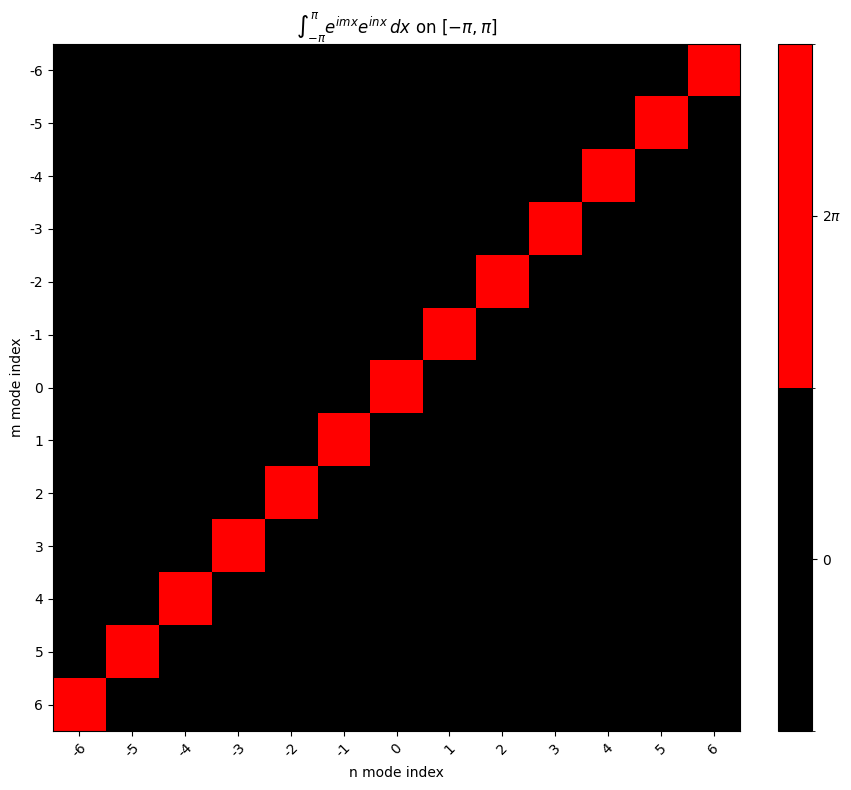

In [3]:
# Non-conjugated integral matrix: int e^{imx} e^{inx} dx

def inner_product_no_conj(f_vals, g_vals, x_grid):
    return np.trapezoid(f_vals * g_vals, x_grid)

EN = np.zeros((len(modes), len(modes)), dtype=complex)
for i, m in enumerate(modes):
    for j, n in enumerate(modes):
        EN[i, j] = inner_product_no_conj(exp_mode(m, x), exp_mode(n, x), x)

print('Real part of non-conjugated integral ≈')
print(np.round(EN.real, 6))
print('\nImaginary part (should be near 0) ≈')
print(np.round(EN.imag, 6))

# Snap to 0 or 2pi for a clean view
tol = 1e-6
EN_real = EN.real
EN_snap = np.zeros_like(EN_real)
EN_snap[np.isclose(EN_real, 2 * np.pi, atol=tol)] = 2 * np.pi

EN_plot = np.zeros_like(EN_snap, dtype=int)
EN_plot[np.isclose(EN_snap, 2 * np.pi)] = 1  # 0->black, 1->red

cmap2 = ListedColormap(['black', 'red'])
norm2 = BoundaryNorm([-0.5, 0.5, 1.5], cmap2.N)

fig2, ax2 = plt.subplots(figsize=(10, 8))
im2 = ax2.imshow(EN_plot, cmap=cmap2, norm=norm2)
ax2.set_title(r'$\int_{-\pi}^{\pi} e^{imx}e^{inx}\,dx$ on $[-\pi,\pi]$')
ax2.set_xlabel('n mode index')
ax2.set_ylabel('m mode index')
ax2.set_xticks(range(len(modes)))
ax2.set_yticks(range(len(modes)))
ax2.set_xticklabels(modes, rotation=45)
ax2.set_yticklabels(modes)
cb2 = fig2.colorbar(im2, ax=ax2, ticks=[0, 1], fraction=0.046, pad=0.04)
cb2.ax.set_yticklabels(['0', r'$2\pi$'])

plt.tight_layout()
plt.show()